In [57]:
import keras
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Dense, Activation, Conv2D, MaxPooling2D, Flatten
import random
import math 
random.seed(10)
from keras.models import Model
from keras.layers import Input, Dense,Dropout
import seaborn as sns 
import pandas as pd 


#generate training data 
n=1000
x1 = np.random.randn(n)
x2 = np.random.randn(n)
epsilon=np.random.normal(0, 1, n)
x = np.array([x1, x2])
x = np.transpose(x)


w11=np.random.uniform(-1,1,1)
w12=np.random.uniform(-1,1,1)
w2=np.random.uniform(-1,1,1)

B1=np.random.uniform(-1,1,1)
B2=np.random.uniform(-1,1,1)

y=np.ones(n)

for i in range(0,n):
    H1=B1+(w11*x1[i])+(w12*x2[i])
    H2=B2+(w2*H1)
    y[i]=H2
    
print(y.shape)
print(x.shape)


(1000,)
(1000, 2)


In [76]:
from tensorflow.keras import layers
from tensorflow.keras import activations
random.seed(10)

#learn model parameters using a simple model w/o dropout 

model = Sequential()
model.add(keras.layers.Dense(1,input_shape=(2,), activation="linear"))
model.add(keras.layers.Dense(1, activation="linear"))

opt = optimizers.Nadam(learning_rate=0.001)
model.compile(loss="mse", optimizer=opt)
hist=model.fit(x, y, epochs=30)

model.summary()


layer1_weights=model.get_weights()[0]
layer1_biases=model.get_weights()[1]
layer2_weights=model.get_weights()[2]
layer2_biases=model.get_weights()[3]

w11=layer1_weights[0]
w12=layer1_weights[1]
w2=layer2_weights[0]
B1=layer1_biases[0]
B2=layer2_biases[0]

print(w11, w12, w2, B1, B2)

Epoch 1/30
32/32 [==============================] - 1s 4ms/step - loss: 1.6898
Epoch 2/30
32/32 [==============================] - 0s 3ms/step - loss: 1.4939
Epoch 3/30
32/32 [==============================] - 0s 3ms/step - loss: 1.3219
Epoch 4/30
32/32 [==============================] - 0s 4ms/step - loss: 1.1756
Epoch 5/30
32/32 [==============================] - 0s 3ms/step - loss: 1.0481
Epoch 6/30
32/32 [==============================] - 0s 3ms/step - loss: 0.9371
Epoch 7/30
32/32 [==============================] - 0s 3ms/step - loss: 0.8400
Epoch 8/30
32/32 [==============================] - 0s 3ms/step - loss: 0.7564
Epoch 9/30
32/32 [==============================] - 0s 4ms/step - loss: 0.6821
Epoch 10/30
32/32 [==============================] - 0s 4ms/step - loss: 0.6168
Epoch 11/30
32/32 [==============================] - 0s 3ms/step - loss: 0.5582
Epoch 12/30
32/32 [==============================] - 0s 2ms/step - loss: 0.5060
Epoch 13/30
32/32 [==============================

In [60]:
#now, retrain the model many times using dropout 
#there will be variability in model parameters due to random dropout 

Nsim=50
layer1_weights=[0] * Nsim
layer1_biases=[0] * Nsim
layer2_weights=[0] * Nsim
layer2_biases=[0] * Nsim

w11_hat=[0] * Nsim
w12_hat=[0] * Nsim
w2_hat=[0] * Nsim

B1_hat=[0] * Nsim
B2_hat=[0] * Nsim


for i in range(0, Nsim):
    model = Sequential()
    model.add(keras.layers.Dense(1,input_shape=(2,), activation="linear"))
    model.add(keras.layers.Dropout(0.1))
    model.add(keras.layers.Dense(1, activation="linear"))

    opt = optimizers.Nadam(learning_rate=0.001)
    model.compile(loss="mse", optimizer=opt)
    hist=model.fit(x, y, epochs=30)
    
    weights=model.get_weights()
    
    layer1_weights[i]=weights[0]
    layer1_biases[i]=weights[1]
    layer2_weights[i]=weights[2]
    layer2_biases[i]=weights[3]

    w11_hat[i]=layer1_weights[i][0]
    w12_hat[i]=layer1_weights[i][1]
    w2_hat[i]=layer2_weights[i][0]
    B1_hat[i]=layer1_biases[i][0]
    B2_hat[i]=layer2_biases[i][0]
    


Epoch 1/30
32/32 [==============================] - 0s 1ms/step - loss: 0.0220
Epoch 2/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0141
Epoch 3/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0092
Epoch 4/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0065
Epoch 5/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0051
Epoch 6/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0044
Epoch 7/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0041
Epoch 8/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0039
Epoch 9/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0039
Epoch 10/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0039
Epoch 11/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0038
Epoch 12/30
32/32 [==============================] - 0s 2ms/step - loss: 0.0038
Epoch 13/30
32/32 [==============================

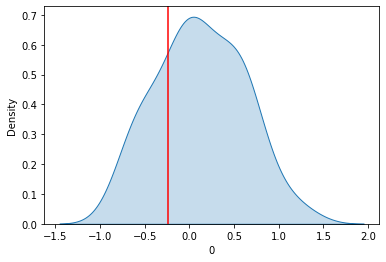

In [61]:
#we can look the distribution of the weights and biases accross many different iterations of dropout 

w11_hat=pd.DataFrame(w11_hat)
sns.kdeplot(w11_hat[0], shade=True)
plt.axvline(w11, color='red')


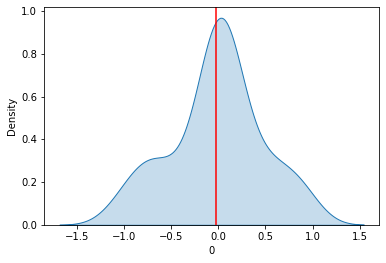

In [62]:
w12_hat=pd.DataFrame(w12_hat)
sns.kdeplot(w12_hat[0], shade=True)
plt.axvline(w12, color='red')

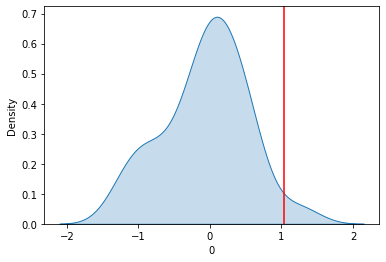

In [63]:
w2_hat=pd.DataFrame(w2_hat)
sns.kdeplot(w2_hat[0], shade=True)
plt.axvline(w2, color='red')

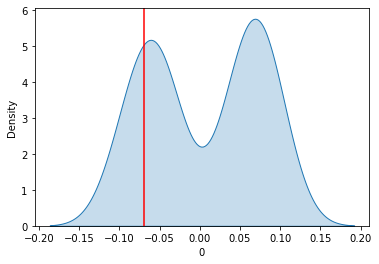

In [64]:
B1_hat=pd.DataFrame(B1_hat)
sns.kdeplot(B1_hat[0], shade=True)
plt.axvline(B1, color='red')

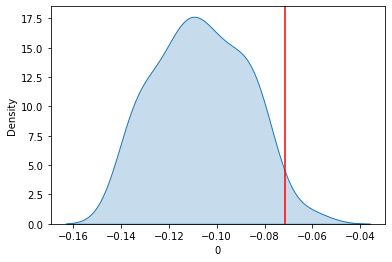

In [65]:
B2_hat=pd.DataFrame(B2_hat)
sns.kdeplot(B2_hat[0], shade=True)
plt.axvline(B2, color='red')

In [ ]:
#Excercise:

#play around with the value of p and the number of layers for dropout
#how does the distribution/variability of the model parameters change? 
#what happens if we increase the complexity of the model (add more layers, change activation, etc.)

